# Figuras del Capítulo 5 — Experimentos y resultados (autocontenido)

Este notebook genera **todas** las figuras del capítulo sin depender de otros cuadernos: carga el corpus,
precalcula las representaciones compartidas y ejecuta los experimentos necesarios in situ. Las tablas que
provienen de la validación cruzada repetida con *bootstrap* (Mixup, nº de muestras, encoders, cross-corpus)
se embeben desde `RESULTS.md`, por ser inviable recomputarlas en una sola pasada.

Cada figura se guarda en `images/` en PDF (vectorial) y PNG. Ejecuta las celdas en orden.

## 0. Configuración, utilidades e importaciones

In [6]:
import numpy as np, torch, warnings
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')

Path('images').mkdir(exist_ok=True)
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)
print('Device:', DEVICE)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'font.size': 11,

    # Fondo blanco
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',

    # Texto y ejes negros
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',

    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

C_TEMP,C_SPEC,C_FUS,C_BASE,C_AUG = '#2A9D8F','#8E7CC3','#E76F51','#4C72B0','#9B59B6'

# Estilo de las barras de error: blancas para que se vean sobre fondo oscuro.
# Se reutiliza en todas las figuras para mantener un aspecto homogéneo.
ERR_KW = dict(ecolor='black', elinewidth=1.2, capthick=1.2)

def save(name):
    plt.savefig(f'images/{name}.pdf'); plt.savefig(f'images/{name}.png', dpi=200)
    print('guardada:', f'images/{name}.pdf')

def ic_err(v,lo,hi):
    v,lo,hi = map(np.asarray,(v,lo,hi)); return np.vstack([v-lo, hi-v])

Device: mps


## 1. Carga y preprocesado de PC-GITA (una sola vez)

Se reutiliza el mismo *pipeline* de la memoria: remuestreo a 16 kHz, normalización de pico y recorte de
silencios. Las representaciones derivadas se calculan una vez y se comparten entre figuras.

In [7]:
from src.preprocessing import load_metadata, load_waveforms, preprocess_waveform

BASE_PATH = 'data'
df = load_metadata(base_path=BASE_PATH)
waveforms, df = load_waveforms(df, target_sr=16000)
waveforms_proc = [preprocess_waveform(w) for w in waveforms]
labels = df['label'].to_numpy()
print('Sujetos:', len(waveforms_proc), '| clases:', dict(zip(*np.unique(labels, return_counts=True))))

Sujetos: 100 | clases: {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}


## 2. Representaciones compartidas: temporal (capa 0) y espectral (ResNet18)

**Rama temporal.** Se extrae la salida del codificador convolucional de wav2vec 2.0 (`hidden_states[0]`,
la 'capa 0' de bajo nivel acústico) y se promedia en el tiempo → vector de 768 por sujeto.

**Rama espectral.** El log-Mel procesado por ResNet18-ImageNet congelada → vector de 512 por sujeto.

In [8]:
from transformers import Wav2Vec2Model
from src.spectral import extract_spectral_features

def extract_layer_embeddings(waveforms, model_name, n_layers, device=DEVICE):
    """Devuelve {capa: (N, D)} usando hidden_states[capa]. capa 0 = salida del CNN encoder."""
    m = Wav2Vec2Model.from_pretrained(model_name, output_hidden_states=True).to(device).eval()
    for p in m.parameters(): p.requires_grad = False
    out = {l: [] for l in range(n_layers)}
    with torch.no_grad():
        for i, wf in enumerate(waveforms):
            x = torch.tensor(wf, dtype=torch.float32).unsqueeze(0).to(device)
            hs = m(x).hidden_states            # 13 tensores: [0]=CNN, [1..12]=Transformer
            for l in range(n_layers):
                out[l].append(hs[l].mean(1).squeeze(0).cpu().numpy())
            if (i+1) % 25 == 0: print(f'  {i+1}/{len(waveforms)}')
    return {l: np.array(v) for l, v in out.items()}

# Barrido por capas (0..12) — se reutiliza en la figura 5.2 y para la rama temporal (capa 0)
layer_emb = extract_layer_embeddings(waveforms_proc, 'facebook/wav2vec2-base', n_layers=13)
emb_t = layer_emb[0]                                  # rama temporal (capa 0), (N, 768)
emb_s = extract_spectral_features(waveforms_proc, device=DEVICE)  # rama espectral, (N, 512)
print('emb_t:', emb_t.shape, '| emb_s:', emb_s.shape)

2026-07-12 19:08:05,118 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-12 19:08:05,183 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-07-12 19:08:05,285 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-12 19:08:05,385 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-12 19:08:05,556 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-07-12 19:08:05,699 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Fou

  25/100
  50/100
  75/100


2026-07-12 19:08:08,790 [INFO] src.config: Generando mel-espectrogramas...
2026-07-12 19:08:08,858 [INFO] src.config:   100 espectrogramas generados
2026-07-12 19:08:08,859 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-07-12 19:08:08,859 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...


  100/100


2026-07-12 19:08:09,074 [INFO] src.config:   25/100
2026-07-12 19:08:09,141 [INFO] src.config:   50/100
2026-07-12 19:08:09,209 [INFO] src.config:   75/100
2026-07-12 19:08:09,275 [INFO] src.config:   100/100
2026-07-12 19:08:09,276 [INFO] src.config:   Features espectrales: (100, 512)


emb_t: (100, 768) | emb_s: (100, 512)


## 5.1 — Líneas base: AUC, sensibilidad y especificidad

**Concepto.** El AUC mide el poder discriminativo con independencia del umbral. Se entrena cada arquitectura
desde cero con validación cruzada de 5 particiones a nivel de sujeto y búsqueda de (lr, batch).

**Para qué sirve.** Muestra que las líneas base no superan de forma robusta el azar en sensibilidad, lo que
motiva el uso de modelos preentrenados.

> Celda larga: entrena todas las líneas base. Reduce `MODEL_CONFIG` si quieres una corrida rápida.

In [9]:
import json
from pathlib import Path
from src.models import (CNN1D, Cnn1dLight, SincNet, WaveNetLike, TemporalTransformer,
                        BiLSTM_CNN, CNNAttention, ECAPA_TDNN, Res1D)
from src.models_marta import InceptionTime, CDIL_CNN
from src.training import run_kfold_search

# El entrenamiento desde cero de las 11 arquitecturas tarda ~4 h. Para poder
# regenerar las figuras sin reentrenar, cacheamos el resultado en disco:
#   - si existe baseline_results.json -> se carga (segundos)
#   - si no existe -> se entrena una vez y se guarda automáticamente
# Borra el fichero si quieres forzar un reentrenamiento completo.
BASELINE_JSON = Path('results/baseline_results.json')

if BASELINE_JSON.exists():
    baseline_results = json.load(open(BASELINE_JSON))
    print('baseline_results cargado desde', BASELINE_JSON, '->', list(baseline_results))
else:
    WINDOW_LEN, HOP_LEN = 12000, 6000
    lite = {'lr':[5e-4, 1e-4], 'batch_size':[4, 8]}
    HYPERPARAM_GRID = {k: lite for k in
        ['CNN1D','CNN1D-Light','SincNet','WaveNet-like','TemporalTransformer',
         'BiLSTM-CNN','CNN-Attention','ECAPA-TDNN','Res1D','InceptionTime','CDIL-CNN']}
    MODEL_CONFIG = {
        'CNN1D':{'class':CNN1D,'patience':10,'epochs':50},
        'CNN1D-Light':{'class':Cnn1dLight,'patience':10,'epochs':50},
        'SincNet':{'class':SincNet,'patience':10,'epochs':50},
        'WaveNet-like':{'class':WaveNetLike,'patience':10,'epochs':50},
        'TemporalTransformer':{'class':TemporalTransformer,'patience':10,'epochs':50},
        'BiLSTM-CNN':{'class':BiLSTM_CNN,'patience':10,'epochs':50},
        'CNN-Attention':{'class':CNNAttention,'patience':10,'epochs':50},
        'ECAPA-TDNN':{'class':ECAPA_TDNN,'patience':10,'epochs':50},
        'Res1D':{'class':Res1D,'patience':10,'epochs':50},
        'InceptionTime':{'class':InceptionTime,'patience':10,'epochs':50},
        'CDIL-CNN':{'class':CDIL_CNN,'patience':10,'epochs':50},
    }
    baseline_results = run_kfold_search(df=df, waveforms_processed=waveforms_proc,
        model_config=MODEL_CONFIG, hyperparam_grid=HYPERPARAM_GRID,
        n_folds=5, random_state=RANDOM_STATE, window_len=WINDOW_LEN, hop_len=HOP_LEN)
    json.dump(
        {k: {kk: vv for kk, vv in v.items() if kk != 'fold_details'}
         for k, v in baseline_results.items()},
        open(BASELINE_JSON, 'w'), indent=2, default=float)
    print('baseline_results entrenado y guardado en', BASELINE_JSON, '->', list(baseline_results))


baseline_results cargado desde results/baseline_results.json -> ['CNN1D', 'CNN1D-Light', 'SincNet', 'WaveNet-like', 'TemporalTransformer', 'BiLSTM-CNN', 'CNN-Attention', 'ECAPA-TDNN', 'Res1D', 'InceptionTime', 'CDIL-CNN']


guardada: images/res_baselines_auc.pdf


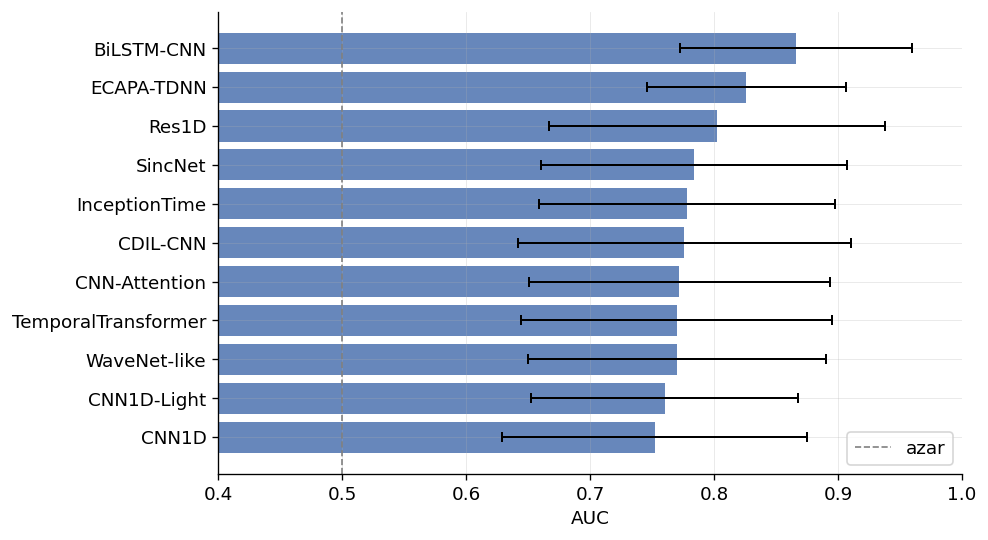

guardada: images/res_baselines_sens_spec.pdf


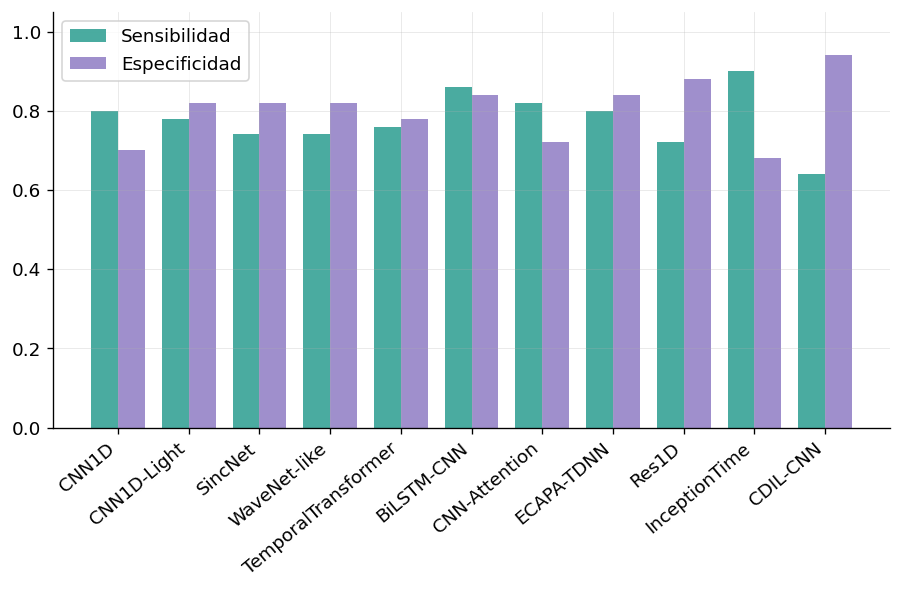

In [10]:
# Figura AUC por modelo
data = {k:(r['auc_mean'], r['auc_std']) for k,r in baseline_results.items()}
order = sorted(data, key=lambda k: data[k][0])
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(order, [data[k][0] for k in order], xerr=[data[k][1] for k in order],
        color=C_BASE, alpha=0.85, capsize=3, error_kw=ERR_KW)
ax.axvline(0.5, ls='--', c='gray', lw=1, label='azar'); ax.set_xlabel('AUC'); ax.set_xlim(0.4,1.0); ax.legend()
save('res_baselines_auc'); plt.show()

# Figura sensibilidad vs especificidad
labs = list(baseline_results); x = np.arange(len(labs)); w = 0.38
sens = [baseline_results[k]['sens_mean'] for k in labs]
spec = [baseline_results[k]['spec_mean'] for k in labs]
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(x-w/2, sens, w, label='Sensibilidad', color=C_TEMP, alpha=0.85)
ax.bar(x+w/2, spec, w, label='Especificidad', color=C_SPEC, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=40, ha='right'); ax.set_ylim(0,1.05); ax.legend()
save('res_baselines_sens_spec'); plt.show()

## 5.2 — Selección de capa de wav2vec 2.0

**Para qué sirve.** Evalúa cada capa (0 = CNN acústico … 12 = último Transformer) como extractor congelado
con PCA+SVM, confirmando que la capa inicial es la más discriminativa para la EP.

guardada: images/res_layer_auc.pdf


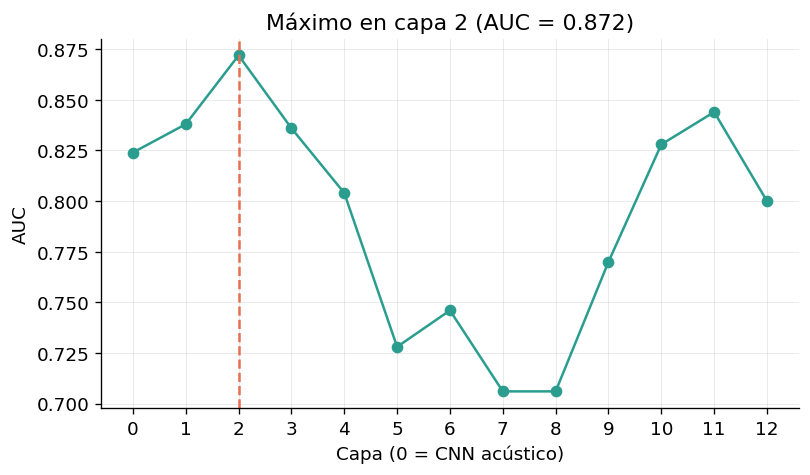

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

def cv_auc(X, y, n_folds=5):
    skf = StratifiedKFold(n_folds, shuffle=True, random_state=RANDOM_STATE); aucs=[]
    for tr, va in skf.split(X, y):
        sc = StandardScaler().fit(X[tr])
        p = PCA(n_components=min(10, X[tr].shape[0], X.shape[1])).fit(sc.transform(X[tr]))
        svm = SVC(C=1.0, kernel='rbf', probability=True, random_state=RANDOM_STATE)
        svm.fit(p.transform(sc.transform(X[tr])), y[tr])
        prob = svm.predict_proba(p.transform(sc.transform(X[va])))[:,1]
        aucs.append(roc_auc_score(y[va], prob))
    return np.mean(aucs)

layer_auc = {l: cv_auc(layer_emb[l], labels) for l in sorted(layer_emb)}
xs = sorted(layer_auc); ys = [layer_auc[l] for l in xs]; best = max(layer_auc, key=layer_auc.get)
fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(xs, ys, '-o', color=C_TEMP); ax.axvline(best, ls='--', c=C_FUS)
ax.set_xticks(xs); ax.set_xlabel('Capa (0 = CNN acústico)'); ax.set_ylabel('AUC')
ax.set_title(f'Máximo en capa {best} (AUC = {layer_auc[best]:.3f})')
save('res_layer_auc'); plt.show()

## 5.3 — Espectrograma log-Mel: EP frente a control

**Para qué sirve.** Muestra la entrada de la rama espectral y las diferencias de estabilidad armónica y
ritmo entre un paciente y un control.

guardada: images/res_logmel_ep_hc.pdf


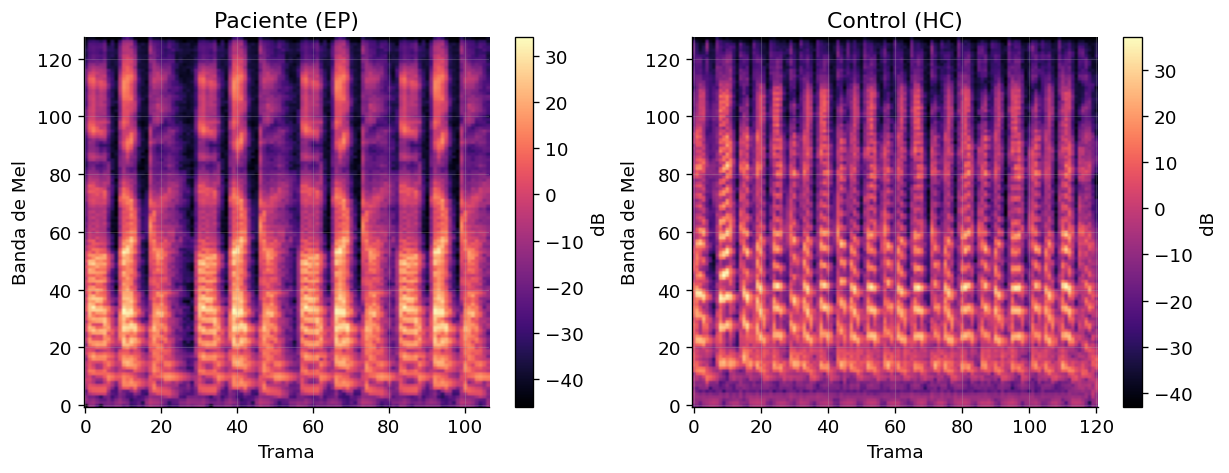

In [12]:
from src.spectral import generate_mel_spectrograms
import polars as pl
MEL = dict(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=128)
i_pd = df.with_row_index().filter(pl.col('label')==1)['index'][0]
i_hc = df.with_row_index().filter(pl.col('label')==0)['index'][0]
mels = generate_mel_spectrograms([waveforms_proc[i_pd], waveforms_proc[i_hc]], **MEL)
fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, m, t in zip(axes, mels, ['Paciente (EP)','Control (HC)']):
    im = ax.imshow(m, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(t); ax.set_xlabel('Trama'); ax.set_ylabel('Banda de Mel'); fig.colorbar(im, ax=ax, label='dB')
save('res_logmel_ep_hc'); plt.show()

## 5.4 — Ablación de la fusión y entrenamiento de DBFNet

**Concepto.** Se comparan la rama temporal, la espectral y su fusión (PCA+SVM) para verificar la
complementariedad. Después se entrena DBFNet por particiones, recogiendo predicciones fuera de muestra,
coeficientes $\alpha$ e historiales de pérdida que se reutilizan en 5.6 y 5.7.

2026-07-12 19:08:10,616 [INFO] src.config: 
2026-07-12 19:08:10,616 [INFO] src.config:   Temporal (capa 0) (768-dim) → PCA + SVM
2026-07-12 19:08:10,617 [INFO] src.config: ============================================================
2026-07-12 19:08:10,649 [INFO] src.config:   PCA=5   C=0.1   kernel=linear  → AUC=0.794
2026-07-12 19:08:10,715 [INFO] src.config:   PCA=5   C=1.0   kernel=linear  → AUC=0.794
2026-07-12 19:08:11,063 [INFO] src.config:   PCA=5   C=10.0  kernel=linear  → AUC=0.794
2026-07-12 19:08:11,097 [INFO] src.config:   PCA=10  C=0.1   kernel=linear  → AUC=0.822
2026-07-12 19:08:11,111 [INFO] src.config:   PCA=10  C=1.0   kernel=rbf     → AUC=0.826
2026-07-12 19:08:11,176 [INFO] src.config:   PCA=10  C=1.0   kernel=linear  → AUC=0.834
2026-07-12 19:08:11,191 [INFO] src.config:   PCA=10  C=10.0  kernel=rbf     → AUC=0.794
2026-07-12 19:08:11,716 [INFO] src.config:   PCA=10  C=10.0  kernel=linear  → AUC=0.834
2026-07-12 19:08:11,757 [INFO] src.config:   PCA=20  C=0.1   ke

guardada: images/res_ablacion_fusion.pdf


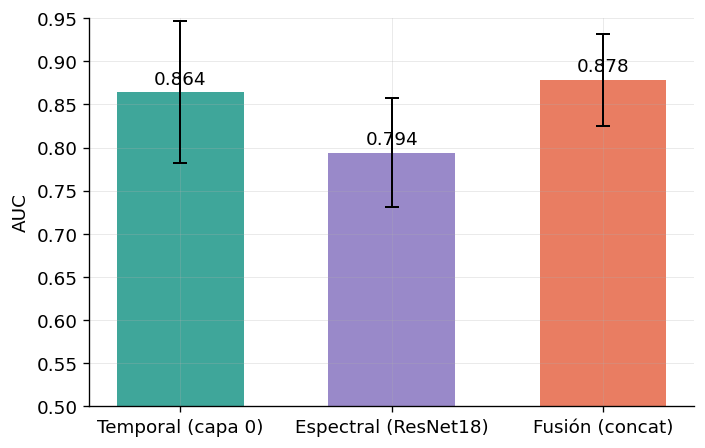

In [13]:
from src.embeddings import run_fusion_svm_search
fusion_cfg = {'Temporal (capa 0)': emb_t, 'Espectral (ResNet18)': emb_s,
              'Fusión (concat)': np.concatenate([emb_t, emb_s], axis=1)}
abl = run_fusion_svm_search(fusion_cfg, labels, pca_components=[5,10,20],
        svm_c=[0.1,1.0,10.0], svm_kernels=['rbf','linear'], n_folds=5, random_state=RANDOM_STATE)
labs = list(abl); vals = [abl[k]['auc_mean'] for k in labs]; errs = [abl[k]['auc_std'] for k in labs]
fig, ax = plt.subplots(figsize=(6.5,4.2))
ax.bar(labs, vals, yerr=errs, color=[C_TEMP,C_SPEC,C_FUS], alpha=0.9, width=0.6, capsize=4, error_kw=ERR_KW)
for i,v in enumerate(vals): ax.text(i, v+0.01, f'{v:.3f}', ha='center')
ax.set_ylabel('AUC'); ax.set_ylim(0.5,0.95)
save('res_ablacion_fusion'); plt.show()

In [14]:
# Entrenar DBFNet por particiones (embeddings precalculados -> rápido)
from src.training import train_dbfnet_fold_with_history

class DualBranchDataset(torch.utils.data.Dataset):
    def __init__(self, zt, zs, y, idx):
        self.zt = torch.tensor(zt[idx], dtype=torch.float32)
        self.zs = torch.tensor(zs[idx], dtype=torch.float32)
        self.y  = torch.tensor(y[idx],  dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.zt[i], self.zs[i], self.y[i]

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof_true, oof_prob, oof_alpha, histories = [], [], [], []
for tr, va in skf.split(np.arange(len(labels)), labels):
    tr_ds = DualBranchDataset(emb_t, emb_s, labels, tr)
    va_ds = DualBranchDataset(emb_t, emb_s, labels, va)
    yt, yp, al, hist = train_dbfnet_fold_with_history(tr_ds, va_ds, DEVICE)
    oof_true += list(yt); oof_prob += list(yp); oof_alpha += list(al); histories.append(hist)
oof_true, oof_prob, oof_alpha = map(np.array, (oof_true, oof_prob, oof_alpha))
print('DBFNet AUC (out-of-fold):', round(roc_auc_score(oof_true, oof_prob), 3))

DBFNet AUC (out-of-fold): 0.907


### 5.4 — Distribución del coeficiente de fusión $\alpha$

Visualiza el peso relativo aprendido para la rama temporal; su media cuantifica la interpretabilidad de la compuerta.

guardada: images/res_alpha_hist.pdf


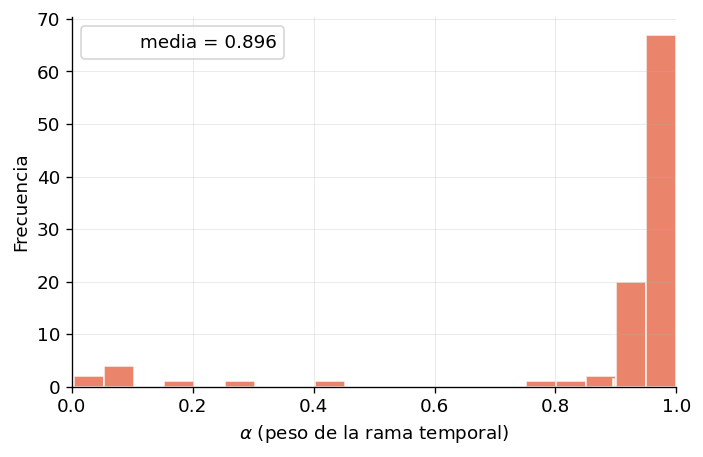

In [15]:
a = oof_alpha.ravel()
fig, ax = plt.subplots(figsize=(6.5,4))
ax.hist(a, bins=20, color=C_FUS, alpha=0.85, edgecolor='white')
ax.axvline(a.mean(), color='white', ls='--', linewidth=1.5, label=f'media = {a.mean():.3f}')
ax.set_xlabel(r'$\alpha$ (peso de la rama temporal)'); ax.set_ylabel('Frecuencia'); ax.set_xlim(0,1); ax.legend()
save('res_alpha_hist'); plt.show()

## 5.5 — Manifold Mixup (datos robustos de `RESULTS.md`)

Estas tres figuras provienen de la validación cruzada repetida (10 reps) con *bootstrap* IC 95 %, cuyo coste
impide recomputarla aquí; los valores se embeben desde `RESULTS.md`. Muestran, respectivamente, la
equivalencia Mixup vs baseline, la ausencia de efecto del nº de muestras y la equivalencia entre encoders.

guardada: images/res_mixup_vs_baseline.pdf


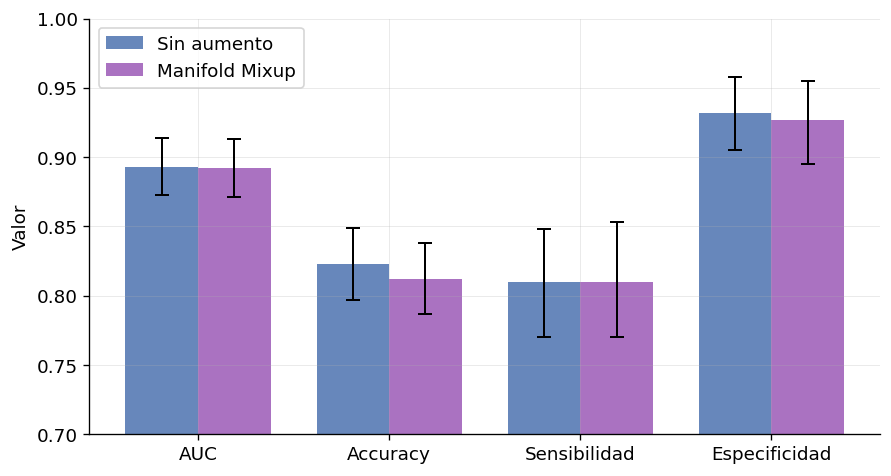

In [16]:
metr = ['AUC','Accuracy','Sensibilidad','Especificidad']
base = dict(val=[0.893,0.823,0.810,0.932], lo=[0.873,0.797,0.770,0.905], hi=[0.914,0.849,0.848,0.958])
mix  = dict(val=[0.892,0.812,0.810,0.927], lo=[0.871,0.787,0.770,0.895], hi=[0.913,0.838,0.853,0.955])
x=np.arange(4); w=0.38; fig,ax=plt.subplots(figsize=(8.5,4.5))
ax.bar(x-w/2, base['val'], w, yerr=ic_err(base['val'],base['lo'],base['hi']), capsize=4, error_kw=ERR_KW, label='Sin aumento', color=C_BASE, alpha=0.85)
ax.bar(x+w/2, mix['val'],  w, yerr=ic_err(mix['val'],mix['lo'],mix['hi']),   capsize=4, error_kw=ERR_KW, label='Manifold Mixup', color=C_AUG, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metr); ax.set_ylim(0.7,1.0); ax.set_ylabel('Valor'); ax.legend()
save('res_mixup_vs_baseline'); plt.show()

guardada: images/res_naug.pdf


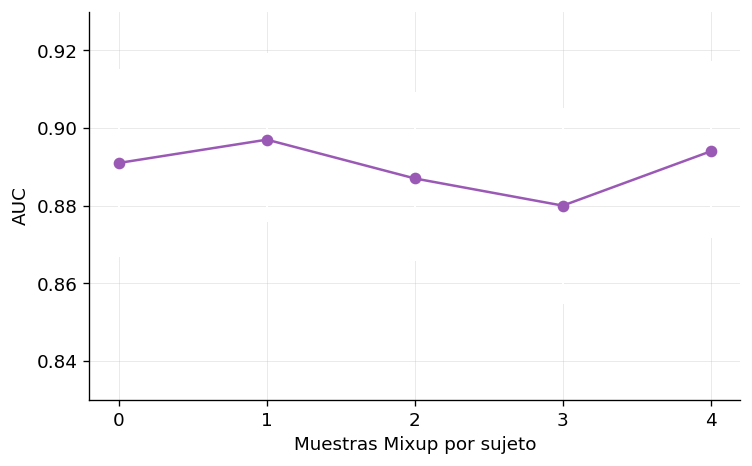

guardada: images/res_encoders.pdf


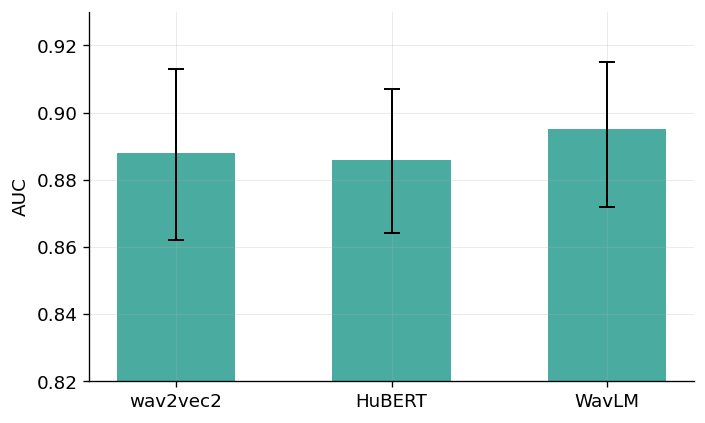

In [17]:
n=[0,1,2,3,4]; auc=[0.891,0.897,0.887,0.880,0.894]; lo=[0.867,0.876,0.866,0.855,0.872]; hi=[0.915,0.919,0.909,0.905,0.917]
fig,ax=plt.subplots(figsize=(7,4.2))
ax.errorbar(n, auc, yerr=ic_err(auc,lo,hi), fmt='-o', color=C_AUG, capsize=4, ecolor='white', elinewidth=1.2, capthick=1.2)
ax.set_xticks(n); ax.set_xlabel('Muestras Mixup por sujeto'); ax.set_ylabel('AUC'); ax.set_ylim(0.83,0.93)
save('res_naug'); plt.show()

enc=['wav2vec2','HuBERT','WavLM']; v=[0.888,0.886,0.895]; lo=[0.862,0.864,0.872]; hi=[0.913,0.907,0.915]
fig,ax=plt.subplots(figsize=(6.5,4))
ax.bar(enc, v, yerr=ic_err(v,lo,hi), capsize=5, error_kw=ERR_KW, color=C_TEMP, alpha=0.85, width=0.55); ax.set_ylabel('AUC'); ax.set_ylim(0.82,0.93)
save('res_encoders'); plt.show()

## 5.6 — Generalización entre corpus y curva ROC

Las barras (intra-corpus y transferencias) proceden de `RESULTS.md`. La ROC se calcula aquí con las
predicciones fuera de muestra de DBFNet en PC-GITA.

guardada: images/res_crosscorpus.pdf


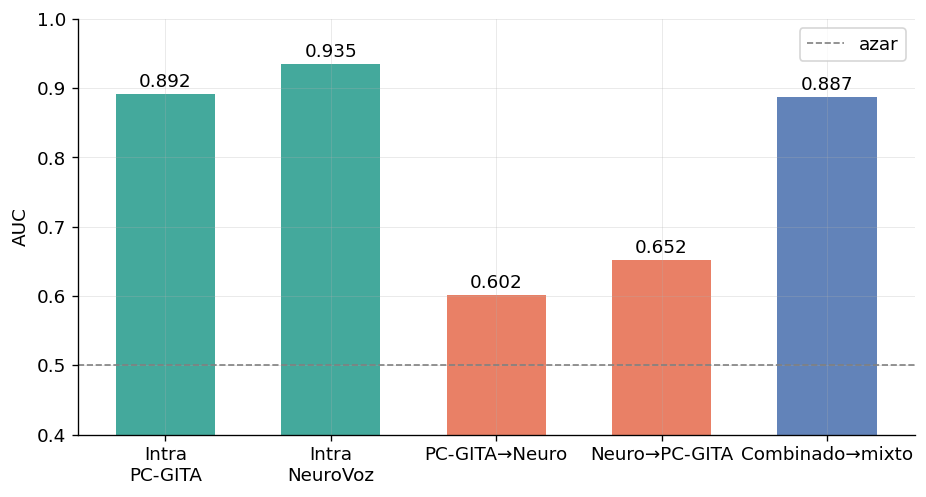

In [18]:
exp=['Intra\nPC-GITA','Intra\nNeuroVoz','PC-GITA\u2192Neuro','Neuro\u2192PC-GITA','Combinado\u2192mixto']
auc=[0.892,0.935,0.602,0.652,0.887]; cols=[C_TEMP,C_TEMP,C_FUS,C_FUS,C_BASE]
fig,ax=plt.subplots(figsize=(9,4.5))
b=ax.bar(exp, auc, color=cols, alpha=0.88, width=0.6); ax.axhline(0.5, ls='--', c='gray', lw=1, label='azar')
for bar,val in zip(b,auc): ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center')
ax.set_ylabel('AUC'); ax.set_ylim(0.4,1.0); ax.legend()
save('res_crosscorpus'); plt.show()

guardada: images/res_roc.pdf


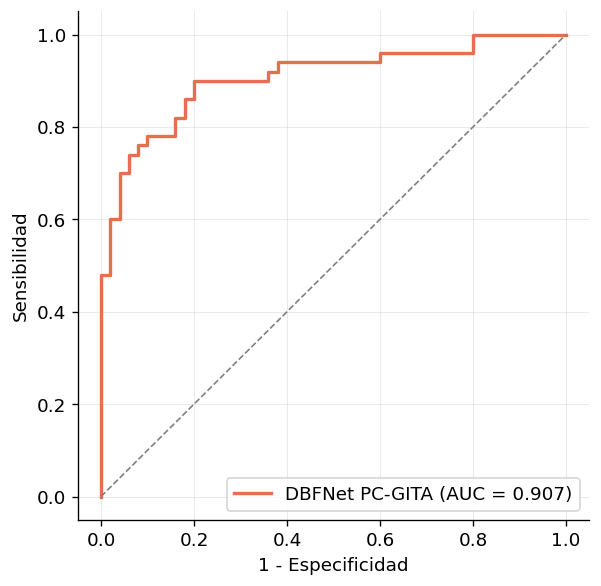

In [19]:
from sklearn.metrics import roc_curve, auc as auc_fn
fpr,tpr,_ = roc_curve(oof_true, oof_prob)
fig,ax=plt.subplots(figsize=(5.5,5.5))
ax.plot(fpr,tpr,color=C_FUS,lw=2,label=f'DBFNet PC-GITA (AUC = {auc_fn(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'--',c='gray',lw=1)
ax.set_xlabel('1 - Especificidad'); ax.set_ylabel('Sensibilidad'); ax.legend(loc='lower right')
save('res_roc'); plt.show()

## 5.7 — Análisis de errores: pérdida por partición y matriz de confusión

Las curvas de pérdida (recogidas durante el entrenamiento de DBFNet) evidencian la ausencia de sobreajuste
severo; la matriz de confusión, con umbral de Youden, muestra el sesgo hacia mayor especificidad.

guardada: images/res_loss_folds.pdf


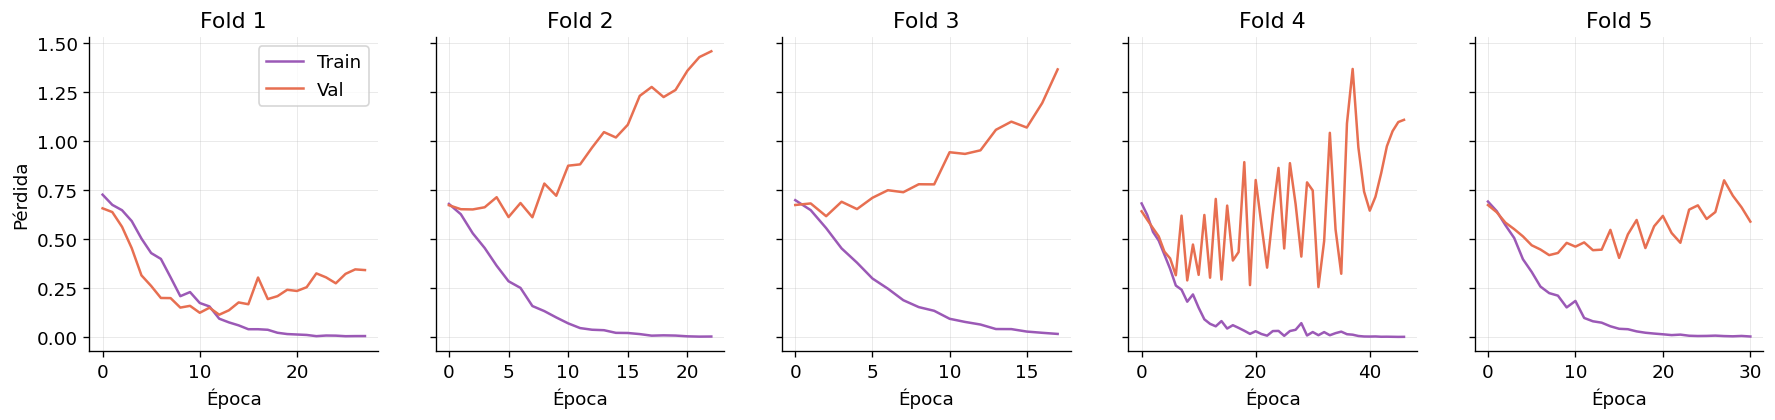

In [20]:
n=len(histories)
fig,axes=plt.subplots(1,n,figsize=(3.6*n,3.4),sharey=True); axes=np.atleast_1d(axes)
for i,(ax,h) in enumerate(zip(axes,histories),1):
    ax.plot(h['train_loss'],color=C_AUG,label='Train'); ax.plot(h['val_loss'],color=C_FUS,label='Val')
    ax.set_title(f'Fold {i}'); ax.set_xlabel('Época')
    if i==1: ax.set_ylabel('Pérdida'); ax.legend()
save('res_loss_folds'); plt.show()

guardada: images/res_confusion.pdf


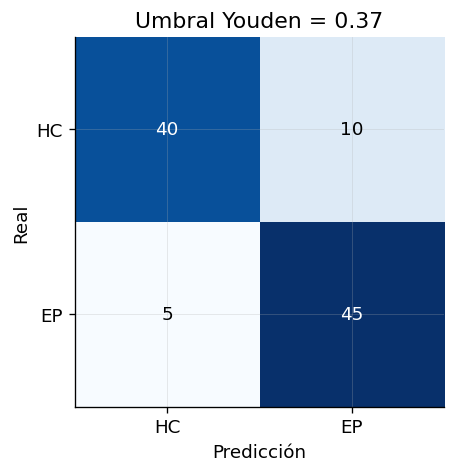

In [21]:
from sklearn.metrics import roc_curve, confusion_matrix
fpr,tpr,thr = roc_curve(oof_true, oof_prob); thr_y = thr[np.argmax(tpr-fpr)]
y_pred = (oof_prob >= thr_y).astype(int)
cm = confusion_matrix(oof_true, y_pred)
fig,ax=plt.subplots(figsize=(4.5,4)); im=ax.imshow(cm,cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1]); ax.set_xticklabels(['HC','EP']); ax.set_yticklabels(['HC','EP'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
ax.set_title(f'Umbral Youden = {thr_y:.2f}')
save('res_confusion'); plt.show()

In [22]:
import json
json.dump(
    {k: {kk: vv for kk, vv in v.items() if kk != "fold_details"}
     for k, v in baseline_results.items()},
    open("results/baseline_results.json", "w"), indent=2, default=float
)
print("guardado:", list(baseline_results))

guardado: ['CNN1D', 'CNN1D-Light', 'SincNet', 'WaveNet-like', 'TemporalTransformer', 'BiLSTM-CNN', 'CNN-Attention', 'ECAPA-TDNN', 'Res1D', 'InceptionTime', 'CDIL-CNN']
